# The Value of Skilled Migration to Australia: A Topic Modeling Analysis of Public Submissions

**Table of Contents**
- Introduction
- Data Ingestion
- Exploratory Data Analysis
  - 1. Basic Analysis
    - 1.1 Pre-processing
    - 1.2 Word Frequencies
  - 2. Topic Modeling (LDA)
- Conclusion
- References

## Introduction

This report analyses the corpus of public submissions made to the Joint Standing Committee on Migration's *Inquiry into the Value of Skilled Migration to Australia*. The corpus consists of 143 PDF submissions from a wide range of stakeholders unions, professional associations, regional development bodies, healthcare and aged care organisations, universities, and individual submitters. Each expressing views on how skilled migration policy affects their sector or community.

**Aim.** The goal of this analysis is to use unsupervised topic modeling (Latent Dirichlet Allocation, LDA) to automatically surface the dominant themes discussed across the submissions, without relying on manual reading of all 143 documents. Discovering these themes at scale helps answer the guiding question of this analysis:

> *What are the main topics of concern and interest that stakeholders raise in response to the Inquiry into the Value of Skilled Migration to Australia, and how are these topics distributed across the submission corpus?*

**Approach.** The analysis follows a standard NLP pipeline: (1) extracting raw text from the source PDFs, (2) exploring the raw corpus statistically to identify data quality issues, (3) cleaning and normalising the text (removing boilerplate, lemmatising, removing stopwords), (4) detecting multi-word phrases (bigrams/trigrams) that carry more specific meaning than single words, and (5) fitting LDA topic models across a range of topic counts, selecting the best model using coherence, perplexity, and topic diversity metrics. Each stage includes an explicit quality checkpoint, since in exploratory NLP work the quality of the input text has a much larger effect on the final result than the choice of modeling algorithm itself.

## Data Ingestion

The raw input data is a folder of 143 PDF files, one per submission, named by submission number (e.g. `Sub007.pdf`). Text is extracted from each PDF using `pdfplumber`, which parses the PDF's internal text layer page by page. The extracted text, together with basic file metadata (filename, file size), is stored in a pandas DataFrame and saved to disk as `submissions_raw.csv` so that later steps do not need to re-parse the PDFs.

Note: a small number of PDFs raise a *"Could not get FontBBox from font descriptor"* warning during extraction. This is a non-fatal warning from the PDF parsing library about a malformed font descriptor in the source PDF (not an error in our code), and `pdfplumber` still recovers the text content in these cases. This is confirmed later in the pre-processing checkpoint.

In [1]:
# ======================================================================
# 1. EXTRACT TEXT FROM PDFs
# ======================================================================
import json
import os
import random
import re
from collections import Counter
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

import pdfplumber

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from IPython.display import HTML, display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

import gensim
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel, Phrases
from gensim.models.phrases import Phraser
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# --- Reproducibility: fix seeds across every relevant generator ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Paths ---
RAW_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/raw"
)
PROCESSED_DATA_PATH = Path(
    "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed"
)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# --- Download required NLTK resources (includes the POS tagger) ---
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                  "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass  # resource names vary slightly across nltk versions; not critical if one fails

print("Setup complete. Fixed seed:", SEED)


def extract_pdf_text(filepath):
    """Extracts plain text from a PDF using pdfplumber."""
    full_text = []
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text.append(text)
        return "\n".join(full_text)
    except Exception as e:
        print(f"Error reading {filepath.name}: {e}")
        return None


pdf_files = list(RAW_DATA_PATH.glob("*.[pP][dD][fF]"))
print(f"Found {len(pdf_files)} PDF files in raw directory.")

records = []
for pdf_path in tqdm(pdf_files, desc="Extracting PDF text"):
    content = extract_pdf_text(pdf_path)
    if content:
        records.append({
            "archivo": pdf_path.name,
            "tamano_bytes": pdf_path.stat().st_size,
            "texto_raw": content,
        })

df = pd.DataFrame(records)
print(f"\nSuccessfully extracted text from {len(df)} PDFs.")

raw_csv_path = PROCESSED_DATA_PATH / "submissions_raw.csv"
df.to_csv(raw_csv_path, index=False)
print(f"Raw data saved to: {raw_csv_path}")

Setup complete. Fixed seed: 42
Found 143 PDF files in raw directory.


Extracting PDF text: 100%|██████████| 143/143 [02:00<00:00,  1.18it/s]


Successfully extracted text from 143 PDFs.
Raw data saved to: /Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_raw.csv


**Result.** All 143 PDFs were parsed successfully (143/143), giving a working DataFrame `df` with one row per submission and a `texto_raw` column holding the extracted plain text. With the raw corpus now loaded, the next section explores its statistical properties before any cleaning is applied, in order to spot data-quality issues (very short documents, numeric/tabular content, encoding artefacts) that would otherwise silently distort the topic model later on.

## Exploratory Data Analysis

Before any text cleaning is applied, it is important to characterise the raw corpus: how long are the submissions, how much lexical variety do they contain, and are there any outlier documents (very short, unusually numeric, or otherwise likely to be low-quality extractions) that should be flagged for later filtering? This section computes a set of descriptive statistics and visualisations over the raw text, which inform the pre-processing decisions made in Section 1.1.

In [2]:
# ======================================================================
# 2. RAW TEXT STATISTICS
# ======================================================================
print("Computing extended raw text metrics...")

df["char_count"] = df["texto_raw"].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df["word_count"] = df["texto_raw"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df["line_count"] = df["texto_raw"].apply(lambda x: len(str(x).splitlines()) if pd.notna(x) else 0)

df["unique_word_count"] = df["texto_raw"].apply(
    lambda x: len(set(str(x).lower().split())) if pd.notna(x) else 0
)
df["avg_word_length"] = df.apply(
    lambda row: row["char_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)
df["lexical_diversity_ttr"] = df.apply(
    lambda row: row["unique_word_count"] / row["word_count"] if row["word_count"] > 0 else 0, axis=1
)

df["uppercase_word_count"] = df["texto_raw"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]) if pd.notna(x) else 0
)
df["digit_count"] = df["texto_raw"].apply(lambda x: len(re.findall(r"\d+", str(x))) if pd.notna(x) else 0)
df["punctuation_count"] = df["texto_raw"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x))) if pd.notna(x) else 0
)

df["digit_ratio"] = df["digit_count"] / df["word_count"].replace(0, 1)
df["uppercase_ratio"] = df["uppercase_word_count"] / df["word_count"].replace(0, 1)

print("\n=== RAW CORPUS OVERALL SUMMARY ===")
print(f"Total Documents: {len(df):,}")
print(f"Total Raw Words (Tokens): {df['word_count'].sum():,}")
print(f"Total Characters: {df['char_count'].sum():,}")
print(f"Average Words per Document: {df['word_count'].mean():.2f} (Std: {df['word_count'].std():.2f})")
print(f"Average Lexical Diversity (Raw TTR): {df['lexical_diversity_ttr'].mean():.4f}")

print("\n=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===")
metrics_to_show = [
    "word_count", "char_count", "line_count", "unique_word_count",
    "avg_word_length", "lexical_diversity_ttr", "digit_ratio", "uppercase_ratio",
]
print(df[metrics_to_show].describe().T[["mean", "std", "min", "50%", "max"]])

print("\n=== EXTREME DOCUMENTS IDENTIFICATION (diagnostic only; filtering applied later) ===")
short_docs = df[df["word_count"] < 100][["archivo", "word_count", "char_count"]]
print(f"Documents with fewer than 100 words: {len(short_docs)}")
if len(short_docs) > 0:
    print(short_docs.head())

high_digit_docs = df[df["digit_ratio"] > 0.1][["archivo", "word_count", "digit_ratio"]]
print(f"\nDocuments with >10% digits (potential data tables): {len(high_digit_docs)}")
if len(high_digit_docs) > 0:
    print(high_digit_docs.head())

Computing extended raw text metrics...

=== RAW CORPUS OVERALL SUMMARY ===
Total Documents: 143
Total Raw Words (Tokens): 535,709
Total Characters: 3,809,735
Average Words per Document: 3746.22 (Std: 5645.99)
Average Lexical Diversity (Raw TTR): 0.3697

=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===
                               mean           std        min           50%  \
word_count              3746.216783   5645.991148  11.000000   2170.000000   
char_count             26641.503497  38888.869984  71.000000  16048.000000   
line_count               381.909091    552.485433   2.000000    232.000000   
unique_word_count       1074.727273    979.390204  11.000000    842.000000   
avg_word_length            7.117404      0.439699   6.201940      7.106764   
lexical_diversity_ttr      0.369680      0.118205   0.037037      0.367595   
digit_ratio                0.052416      0.035578   0.004545      0.042613   
uppercase_ratio            0.017543      0.014997   0.000000      0.

### 1. Basic Analysis

The corpus totals 535,709 raw words across 143 documents, but the spread is extremely wide: submissions average 3,746 words with a standard deviation of 5,646 larger than the mean itself, ranging from an 11 word cover page up to a 41,747 word detailed policy submission. This confirms the corpus is highly heterogeneous in length, which has two consequences for pre-processing: (1) a handful of documents are almost certainly cover pages or placeholders with no real content, and (2) documents with many numeric references (statistics-heavy submissions) should not be penalised purely for their length, since some of the longest documents are also the most substantive. The average digit ratio (5.2%) and the identification of 8 documents exceeding 10% digit content give a first signal of which submissions are more heavily statistical/tabular in nature. This is revisited quantitatively in Section 1.1 when deciding the document-filtering thresholds.

The chart panel below visualises these distributions together with a word cloud of the raw (unprocessed) vocabulary, to get an initial qualitative sense of the corpus content before cleaning.

Generating extended visualization panel including WordCloud...


/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


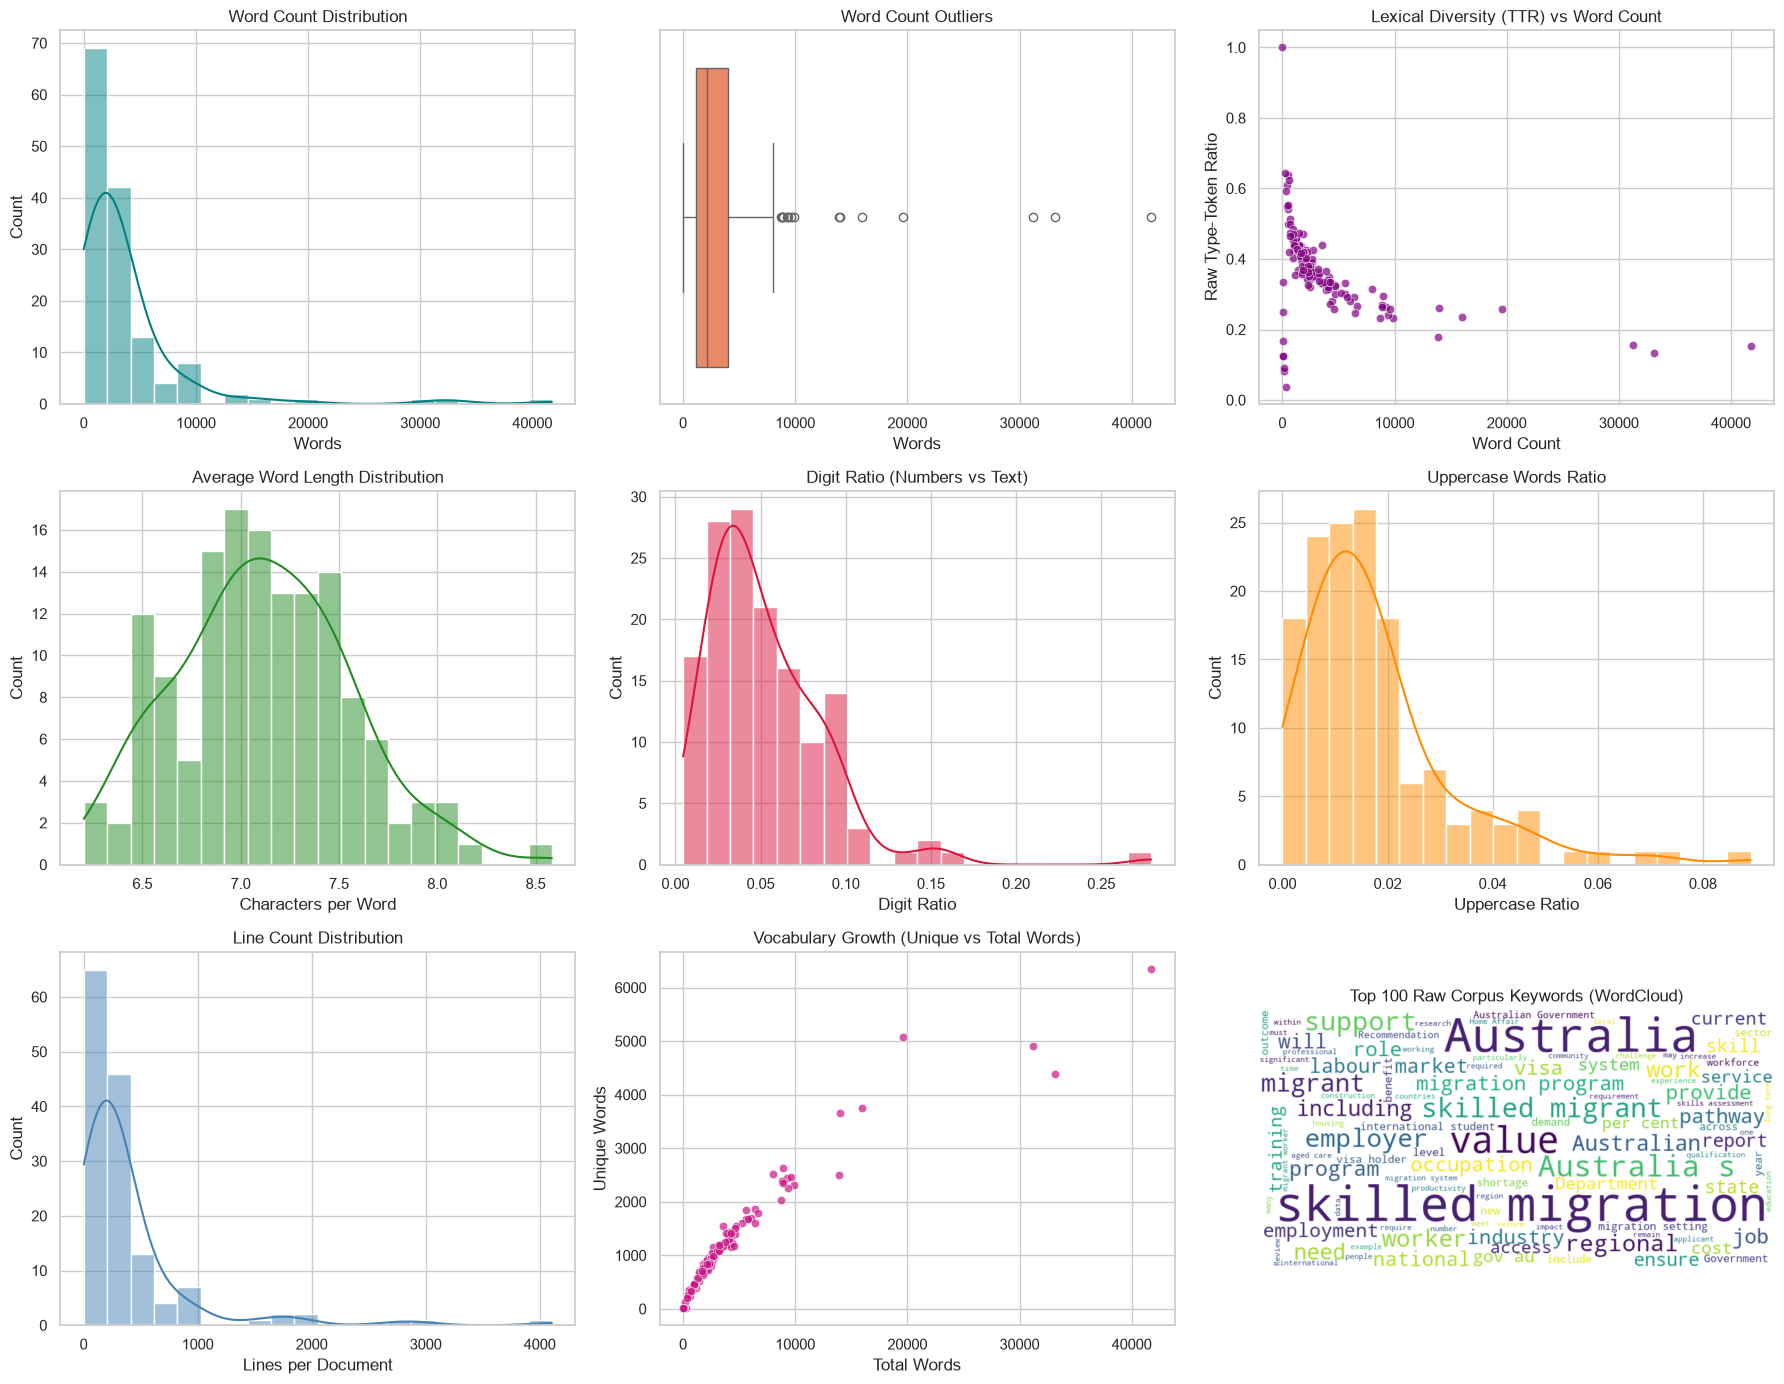

In [3]:
# --- 3x3 visualization panel: raw corpus characteristics ---
print("Generating extended visualization panel including WordCloud...")
all_text = " ".join(df["texto_raw"].dropna().tolist())
custom_wc_stopwords = set(STOPWORDS).union({
    "http", "https", "www", "com", "pdf", "page", "subclass", "submission",
    "inquiry", "committee",
})

wc = WordCloud(
    width=800, height=400, background_color="white",
    stopwords=custom_wc_stopwords, max_words=100, colormap="viridis", random_state=SEED,
).generate(all_text)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.histplot(df["word_count"], kde=True, ax=axes[0, 0], color="teal", bins=20)
axes[0, 0].set_title("Word Count Distribution")
axes[0, 0].set_xlabel("Words")

sns.boxplot(x=df["word_count"], ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Word Count Outliers")
axes[0, 1].set_xlabel("Words")

sns.scatterplot(data=df, x="word_count", y="lexical_diversity_ttr", ax=axes[0, 2], alpha=0.7, color="purple")
axes[0, 2].set_title("Lexical Diversity (TTR) vs Word Count")
axes[0, 2].set_xlabel("Word Count")
axes[0, 2].set_ylabel("Raw Type-Token Ratio")

sns.histplot(df["avg_word_length"], kde=True, ax=axes[1, 0], color="forestgreen", bins=20)
axes[1, 0].set_title("Average Word Length Distribution")
axes[1, 0].set_xlabel("Characters per Word")

sns.histplot(df["digit_ratio"], kde=True, ax=axes[1, 1], color="crimson", bins=20)
axes[1, 1].set_title("Digit Ratio (Numbers vs Text)")
axes[1, 1].set_xlabel("Digit Ratio")

sns.histplot(df["uppercase_ratio"], kde=True, ax=axes[1, 2], color="darkorange", bins=20)
axes[1, 2].set_title("Uppercase Words Ratio")
axes[1, 2].set_xlabel("Uppercase Ratio")

sns.histplot(df["line_count"], kde=True, ax=axes[2, 0], color="steelblue", bins=20)
axes[2, 0].set_title("Line Count Distribution")
axes[2, 0].set_xlabel("Lines per Document")

sns.scatterplot(data=df, x="word_count", y="unique_word_count", ax=axes[2, 1], color="mediumvioletred", alpha=0.7)
axes[2, 1].set_title("Vocabulary Growth (Unique vs Total Words)")
axes[2, 1].set_xlabel("Total Words")
axes[2, 1].set_ylabel("Unique Words")

axes[2, 2].imshow(wc, interpolation="bilinear")
axes[2, 2].axis("off")
axes[2, 2].set_title("Top 100 Raw Corpus Keywords (WordCloud)")

plt.tight_layout()
plt.show()

The word count distribution is heavily right-skewed (confirmed by the boxplot, which shows numerous outliers above the upper whisker), consistent with a small number of very long, detailed submissions alongside many shorter ones. Lexical diversity (Type-Token Ratio) declines as documents get longer an expected pattern, since longer documents naturally reuse the same core vocabulary (*migration, skilled, visa, worker*) more often, driving the ratio down even though their *absolute* vocabulary keeps growing, as shown in the near-linear "vocabulary growth" scatterplot. The raw word cloud is already dominated by *"Inquiry"*, *"skilled"*, *"migration"*, and *"Australia"* expected, since this is the title of the inquiry itself and appears repeatedly as a header on every submission. This repetition is exactly the kind of artefact that needs to be removed before it distorts word-frequency counts and, more importantly, the bigram/trigram detection used for topic modeling later. This is addressed explicitly in the pre-processing step below.

### 1.1 Pre-processing

Several pre-processing decisions were made based on the raw text diagnostics above, each with a specific justification:

- **URL and email removal.** Submission footers commonly include organisational URLs and contact emails (e.g. `unionsnsw.org.au`). If left in, the punctuation stripping step below would fragment these into meaningless pieces (`unionsnsw org au`), which a naive bigram detector could later re-glue into a nonsense token. URLs and emails are therefore removed as a dedicated first step.
- **Boilerplate removal (fuzzy matching).** Every submission repeats the inquiry's own title ("Inquiry into the Value of Skilled Migration to Australia") and its submission number on nearly every page as a header. Left unaddressed, this artificially inflates the frequency of *migration* and *skilled*, and worse gets detected as a spurious high-frequency phrase during bigram/trigram detection. A custom boilerplate detector identifies lines that repeat across at least 30% of documents, using both an exact match and a *fuzzy* similarity match (via `difflib.SequenceMatcher`) so that minor variations in header wording, punctuation, or page numbers are still caught and removed. A dedicated regular expression additionally removes any remaining loose "Submission N" mentions.
- **Contraction expansion.** A naive symbol stripping regex (`[^a-z\s]`) would otherwise turn *"don't"* into *"don t"*, leaving a meaningless orphan token *"don"* in the vocabulary. Common English contractions are expanded first (*"don't" → "do not"*) to avoid this.
- **POS-aware lemmatisation.** Rather than lemmatising every token as if it were a noun (the default behaviour of `WordNetLemmatizer` when no part of speech is supplied), each token is first POS-tagged so that verbs, adjectives and adverbs are correctly reduced to their base form as well (e.g. *"recommends"/"recommended"/"recommending" → "recommend"*), preventing the vocabulary from being artificially inflated with inflected duplicates.
- **Domain-specific stopwords.** In addition to the standard NLTK English stopword list, terms that are structurally common across *every* submission by construction of the inquiry itself (*"submission", "inquiry", "committee", "australia", "parliament", "page", "http", "www", "com", ...*) are removed, since they carry no discriminating power for topic modeling.

The cell below applies URL/boilerplate removal and then the full cleaning and lemmatisation pipeline, followed by a quality checkpoint.

In [4]:
# ======================================================================
# 3. URL / EMAIL / BOILERPLATE REMOVAL (fuzzy matching)
# ======================================================================
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+|\S+\.(?:com|org|gov|edu|au|net)\.?\S*)", re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\S+@\S+\.\S+")


def strip_urls_and_emails(text):
    if not isinstance(text, str):
        return text
    text = EMAIL_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return text


def normalize_line(line):
    """Normalize a line for comparison: lowercase, collapse whitespace."""
    return re.sub(r"\s+", " ", line.strip().lower())


def find_boilerplate_lines(texts, min_doc_fraction=0.3, min_len=15, fuzzy_threshold=0.88):
    """
    Finds lines that appear in at least min_doc_fraction of documents.
    Uses exact matching first, then a number-agnostic pass (so page-numbered
    header variants collapse to the same underlying line), then fuzzy
    matching to catch minor wording/punctuation variations of the same
    repeated header or title.
    """
    n_docs = len(texts)
    normalized_lines_per_doc = []
    for text in texts:
        if not isinstance(text, str):
            normalized_lines_per_doc.append(set())
            continue
        lines = {normalize_line(l) for l in text.splitlines() if len(l.strip()) >= min_len}
        number_agnostic = set()
        for line in lines:
            ag = re.sub(r"\d+", "", line).strip()
            if len(ag) >= min_len:
                number_agnostic.add(ag)
        lines.update(number_agnostic)
        normalized_lines_per_doc.append(lines)

    line_doc_counts = Counter()
    for lines in normalized_lines_per_doc:
        for line in lines:
            line_doc_counts[line] += 1
    threshold = max(2, int(n_docs * min_doc_fraction))
    boilerplate = {line for line, count in line_doc_counts.items() if count >= threshold}

    for lines in normalized_lines_per_doc:
        for line in lines:
            if line in boilerplate:
                continue
            for bp in boilerplate:
                if SequenceMatcher(None, line, bp).ratio() >= fuzzy_threshold:
                    boilerplate.add(line)
                    break
    return boilerplate


def remove_boilerplate(text, boilerplate_set, fuzzy_threshold=0.88):
    if not isinstance(text, str):
        return text
    kept_lines = []
    for raw_line in text.splitlines():
        norm = normalize_line(raw_line)
        if norm in boilerplate_set:
            continue
        is_bp = False
        for bp in boilerplate_set:
            if SequenceMatcher(None, norm, bp).ratio() >= fuzzy_threshold:
                is_bp = True
                break
        if not is_bp:
            kept_lines.append(raw_line)
    return "\n".join(kept_lines)


df["texto_sin_urls"] = df["texto_raw"].apply(strip_urls_and_emails)

boilerplate_lines = find_boilerplate_lines(df["texto_sin_urls"].tolist(), min_doc_fraction=0.3)
print(f"Boilerplate lines detected (appear in >=30% of docs): {len(boilerplate_lines)}")
for line in list(boilerplate_lines)[:10]:
    print("  -", line[:100])

df["texto_sin_boilerplate"] = df["texto_sin_urls"].apply(lambda x: remove_boilerplate(x, boilerplate_lines))
df["texto_sin_boilerplate"] = df["texto_sin_boilerplate"].apply(
    lambda x: re.sub(r"\bsubmission\s*\d+\b", " ", str(x), flags=re.IGNORECASE) if pd.notna(x) else x
)

removed_word_pct = (
    (df["texto_raw"].str.split().str.len() - df["texto_sin_boilerplate"].str.split().str.len())
    / df["texto_raw"].str.split().str.len().replace(0, 1)
) * 100
print(f"\nAverage % of words removed by URL/boilerplate stripping: {removed_word_pct.mean():.2f}%")
print("(Should be a small percentage, roughly 1-10%. If much higher, min_doc_fraction is too loose.)")


# ======================================================================
# 4. CLEANING AND LEMMATIZATION
# ======================================================================
stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "sub", "submission", "inquiry", "committee", "australia", "australian",
    "parliament", "parliamentary", "page", "pdf", "accordance", "attached",
    "http", "https", "www", "com",
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am",
}


def expand_contractions(text):
    text = text.replace("\u2019", "'")  # normalize curly apostrophe to straight
    for pattern, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(pattern) + r"\b", expansion, text)
    return text


def get_wordnet_pos(treebank_tag):
    """Maps NLTK POS tags to the tags WordNetLemmatizer expects, so verbs
    and adjectives get lemmatized correctly (not just nouns)."""
    if treebank_tag.startswith("J"):
        return "a"  # adjective
    elif treebank_tag.startswith("V"):
        return "v"  # verb
    elif treebank_tag.startswith("R"):
        return "r"  # adverb
    else:
        return "n"  # noun (default)


def preprocess_and_lemmatize(text):
    """
    Cleans raw text (already stripped of URLs/boilerplate):
    - Expands contractions
    - Lowercases
    - Removes numbers, punctuation, and non-alphabetic symbols
    - Tokenizes
    - Lemmatizes using real POS tagging (verbs, adjectives, nouns)
    - Removes stopwords and tokens of length <= 2
    """
    if not isinstance(text, str):
        return ""

    text = expand_contractions(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    clean_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(clean_tokens)


print("Cleaning and lemmatizing text corpus...")
tqdm.pandas(desc="Cleaning")
df["texto_limpio"] = df["texto_sin_boilerplate"].progress_apply(preprocess_and_lemmatize)
print("Text preprocessing complete!")

df["clean_word_count"] = df["texto_limpio"].apply(lambda x: len(x.split()))
df["words_removed_%"] = ((df["word_count"] - df["clean_word_count"]) / df["word_count"]) * 100

# --- Quality checkpoint: cleaning ---
print("=" * 70)
print("QUALITY CHECK: TEXT CLEANING")
print("=" * 70)
print(f"Average % of words removed during cleaning: {df['words_removed_%'].mean():.2f}%")
print("If this is above ~70-75%, the cleaning may be too aggressive.\n")

print("--- Sample raw vs. clean text (first 2 documents) ---")
for i in range(min(2, len(df))):
    print(f"\n[Document {i}] RAW (first 200 chars):")
    print(str(df["texto_raw"].iloc[i])[:200])
    print(f"\n[Document {i}] CLEAN (first 200 chars):")
    print(str(df["texto_limpio"].iloc[i])[:200])

ghost_tokens = [w for w in set(" ".join(df["texto_limpio"].dropna()).split())
                if w in {"don", "isn", "wasn", "aren", "doesn", "didn", "hasn", "wouldn"}]
print(f"\nGhost tokens still present (should be empty): {ghost_tokens}")

http_leftovers = [w for w in set(" ".join(df["texto_limpio"].dropna()).split())
                   if w in {"http", "https", "www", "com"}]
print(f"URL-related leftovers (should be empty): {http_leftovers}")

zero_token_docs = df[df["clean_word_count"] == 0][["archivo", "word_count", "clean_word_count"]]
print(f"\nDocuments with 0 clean tokens after cleaning: {len(zero_token_docs)}")
if len(zero_token_docs) > 0:
    print(zero_token_docs)

Boilerplate lines detected (appear in >=30% of docs): 81
  - inquiry into the value of skilled migration to australia - submission 3
  - inquiry into the value of skilled migration to australia 18
  - migration’s inquiry into the value of skilled migration to australia
  - inquiry into the value of skilled migration to australia 26
  - 3 | inquiry into the value of skilled migration to australia
  - inquiry into the value of skilled migration to australia 21
  - inquiry into the value of skilled migration
  - the value of skilled migration
  - inquiry into the value of skilled migration to australia 23
  - inq uiry into the value of skilled migration to australia

Average % of words removed by URL/boilerplate stripping: 10.46%
(Should be a small percentage, roughly 1-10%. If much higher, min_doc_fraction is too loose.)
Cleaning and lemmatizing text corpus...


Cleaning: 100%|██████████| 143/143 [00:14<00:00, 10.20it/s]

Text preprocessing complete!
QUALITY CHECK: TEXT CLEANING
Average % of words removed during cleaning: 44.66%
If this is above ~70-75%, the cleaning may be too aggressive.

--- Sample raw vs. clean text (first 2 documents) ---

[Document 0] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 106
Inquiry into the value of skilled migration to Australia
Submission 106
Who we are
The Federation of Ethnic Communities’ Council

[Document 0] CLEAN (first 200 chars):
federation ethnic community council fecca national peak body represent people culturally linguistically diverse cald community organisation across membership state territory regional ethnic community 

[Document 1] RAW (first 200 chars):
Inquiry into the value of skilled migration to Australia
Submission 112
Inquiry into the value of
Skilled Migration to
Australia
Submission by the Australian Council of Trade Unions
ACTU Submission, D

[Document 1] CLEAN (first 200 chars):
value skilled migra

**Interpretation.** On average, 44.7% of raw words are removed during cleaning (stopwords, boilerplate, punctuation) comfortably below the 70–75% threshold that would indicate over aggressive cleaning. No "ghost tokens" (fragments left over from the apostrophe splitting bug, e.g. *"don"*) or leftover URL fragments (*"http"*, *"www"*) are present in the cleaned vocabulary, confirming that both fixes are working as intended.

Nine documents resulted in zero clean tokens after preprocessing. Initial inspection suggested these were content-free submissions. However, a deeper audit revealed that these files (e.g., Sub110.pdf, Sub141.pdf) are scanned images or non-searchable PDFs lacking an embedded text layer. Because our standard extraction pipeline only reads digital text, no characters were captured. While they are excluded from the current corpus to prevent modeling errors, they represent an OCR extraction bottleneck rather than blank submissions.

### 1.2 Word Frequencies

With the corpus cleaned, the next step is to examine which individual words dominate the vocabulary, both as a sanity check (do the most frequent words make sense for this domain?) and as a first, coarse view of corpus content before moving to the more precise topic modeling in Section 2.

--- Top 50 most frequent words after cleaning ---
migration        6076
skilled          5625
visa             3818
skill            3200
migrant          3151
regional         2415
worker           2316
work             2062
support          1923
program          1882
workforce        1830
employer         1787
labour           1556
shortage         1535
need             1506
government       1444
include          1440
occupation       1393
industry         1383
international    1294
service          1246
economic         1193
business         1178
system           1165
pathway          1141
community        1141
provide          1003
high              976
social            976
sector            965
year              959
permanent         926
also              913
state             908
job               898
role              887
national          874
experience        860
age               860
term              859
student           859
report            853
ensure            830
mark

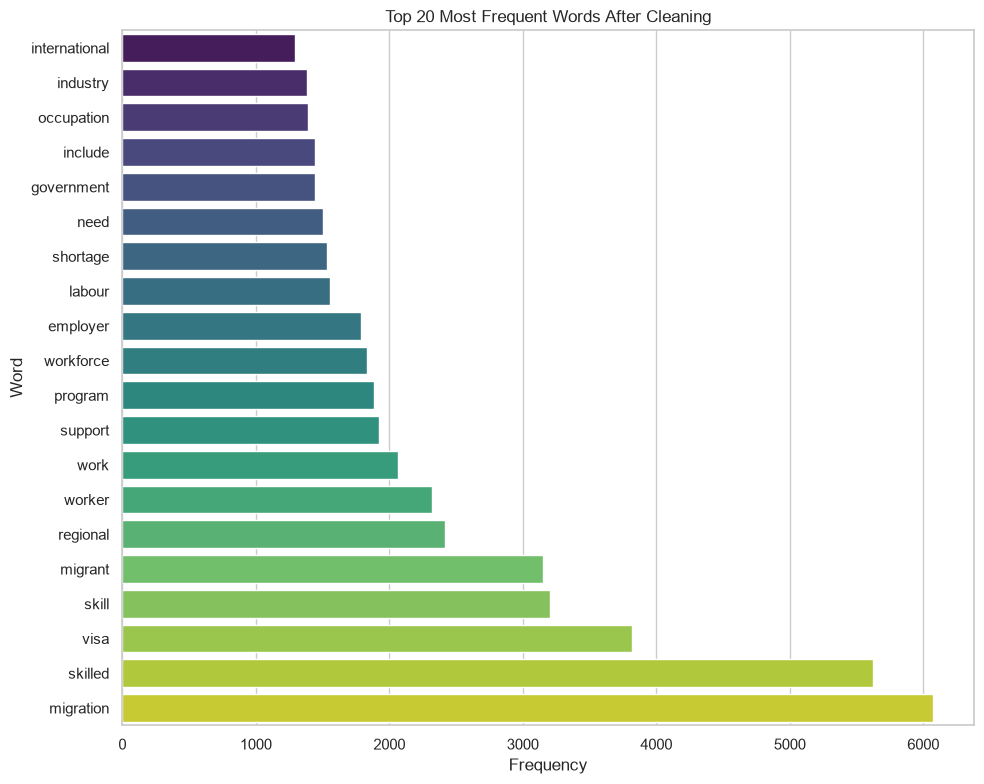

In [5]:
# --- Top word frequencies (bar chart) ---
all_words = " ".join(df["texto_limpio"].dropna()).split()
word_freq = pd.Series(Counter(all_words)).sort_values(ascending=False)

print("--- Top 50 most frequent words after cleaning ---")
print(word_freq.head(50))

plt.figure(figsize=(10, 8))
top20 = word_freq.head(20).sort_values()
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette="viridis", legend=False)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**Interpretation.** The most frequent cleaned tokens *migration, skilled, visa, skill, migrant, regional, worker, work, support, program, workforce, employer, labour, shortage* are exactly what would be expected for submissions to a skilled-migration inquiry, which is a reassuring sanity check that the cleaning pipeline has preserved meaningful content rather than corrupting it. At the same time, these top words are all fairly generic to the inquiry as a whole (they would likely appear at some frequency in almost every submission, regardless of its specific focus), which is precisely why single word frequency counts are not sufficient to distinguish the different *themes* raised by different stakeholders. For example, *"worker"* alone doesn't tell us whether a document is about healthcare workers, PALM scheme workers, or tradespeople. This motivates moving to phrase detection (bigrams/trigrams, which recover more specific concepts like *"age_care"* or *"skill_assessment"*) and topic modeling in the next section, which can identify which *combinations* of words tend to co-occur, revealing the more specific sub-themes within the corpus.

### 2. Topic Modeling (LDA)

**Method.** Latent Dirichlet Allocation (LDA) is used to discover latent topics in the corpus. LDA treats each document as a mixture of topics and each topic as a probability distribution over words, inferring both from the observed word co-occurrence patterns across documents without any manual labelling. Before training, three additional steps are needed: (1) detecting bigrams/trigrams so that multi-word concepts (*"aged_care"*, *"skill_assessment"*) are treated as single tokens instead of being split into less informative individual words; (2) filtering out documents identified as too short or too numeric to contribute a reliable topical signal; and (3) building the gensim dictionary and (bag of words) corpus that LDA requires as input, with frequency based filtering to remove overly rare and overly common tokens that would otherwise add noise or dilute the model.

The cell below performs phrase detection using gensim's `Phrases`, scored with normalised pointwise mutual information (**npmi**) rather than raw frequency. NPMI produces a bounded score between -1 and 1, which makes the detection threshold behave consistently regardless of corpus size with the default frequency based scorer, a fixed threshold does not generalise well across corpora. Phrase length is additionally capped at trigrams, since longer concatenations (four or more words chained together) are almost always artefacts (e.g. addresses, repeated text) rather than genuine multi-word concepts. A small blocklist also removes leftover fragments of the inquiry's own title that survive as phrases even after boilerplate line removal, since these are structural noise rather than topical content.

In [17]:
# ======================================================================
# 5. BIGRAM / TRIGRAM DETECTION (npmi scoring + length cap)
# ======================================================================
tokens_list_raw = [doc.split() for doc in df["texto_limpio"].dropna()]

bigram_model = Phrases(tokens_list_raw, min_count=5, threshold=0.5, scoring="npmi")
bigram_phraser = Phraser(bigram_model)

trigram_model = Phrases(bigram_phraser[tokens_list_raw], min_count=5, threshold=0.5, scoring="npmi")
trigram_phraser = Phraser(trigram_model)

tokens_list = [trigram_phraser[bigram_phraser[doc]] for doc in tokens_list_raw]

TITLE_PHRASE_BLOCKLIST = {
    "value_skilled_migration", "skilled_migration_australia",
    "value_skilled_migration_australia", "skilled_migration",
}


def drop_blocklisted_phrases(doc_tokens, blocklist):
    return [t for t in doc_tokens if t not in blocklist]


tokens_list = [drop_blocklisted_phrases(doc, TITLE_PHRASE_BLOCKLIST) for doc in tokens_list]

MAX_UNDERSCORES = 2  # allows unigrams, bigrams, trigrams
tokens_list = [[t for t in doc if t.count("_") <= MAX_UNDERSCORES] for doc in tokens_list]

# --- Quality checkpoint: phrase detection ---
print("=" * 70)
print("QUALITY CHECK: BIGRAM / TRIGRAM DETECTION")
print("=" * 70)
all_tokens_flat = [tok for doc in tokens_list for tok in doc]
phrase_freq = pd.Series(Counter(t for t in all_tokens_flat if "_" in t)).sort_values(ascending=False)
print("--- Top 20 detected phrases ---")
print(phrase_freq.head(20))

long_chains = [p for p in phrase_freq.index if p.count("_") >= 3]
print(f"\nPhrases with 4+ words chained together (should be 0): {len(long_chains)}")


# ======================================================================
# 6. DOCUMENT FILTERING (too short vs. too numeric)
# ======================================================================
MIN_CLEAN_WORDS = 50
MAX_DIGIT_RATIO = 0.25

df["is_too_short"] = df["clean_word_count"] < MIN_CLEAN_WORDS
df["is_too_numeric"] = df["digit_ratio"] > MAX_DIGIT_RATIO

mask_keep = ~(df["is_too_short"] | df["is_too_numeric"])

print("\n" + "=" * 70)
print("QUALITY CHECK: DOCUMENT FILTERING")
print("=" * 70)
print(f"Documents before filtering: {len(df)}")
print(f"Removed for being too short (<{MIN_CLEAN_WORDS} clean words): {df['is_too_short'].sum()}")
print(f"Removed for being too numeric (digit_ratio > {MAX_DIGIT_RATIO}): {df['is_too_numeric'].sum()}")
print(f"Documents after filtering: {mask_keep.sum()}")

keep_indices = df.index[mask_keep].tolist()
df_filtered = df.loc[mask_keep].reset_index(drop=True)
tokens_list = [tokens_list[i] for i in keep_indices]


# ======================================================================
# 7. DICTIONARY AND CORPUS FOR GENSIM
# ======================================================================
print("\nPreparing dictionary and corpus for LDA...")

dictionary = corpora.Dictionary(tokens_list)
# no_above=0.38, no_below=5: keeps tokens that appear in at least 5
# documents but no more than 38% of documents, controlling vocabulary
# bloat while avoiding the coherence/diversity loss observed when this
# was tightened further to 0.35 in an earlier iteration.
dictionary.filter_extremes(no_below=5, no_above=0.38)

corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

print(f"Dictionary Size (Unique Tokens): {len(dictionary)}")
print(f"Total Processed Documents: {len(corpus)}")

print("\n" + "=" * 70)
print("QUALITY CHECK: DICTIONARY")
print("=" * 70)
sample_size = min(30, len(dictionary))
sample_words = random.sample(list(dictionary.token2id.keys()), sample_size)
print(f"Dictionary size: {len(dictionary)} unique tokens for {len(corpus)} documents")
print("Rule of thumb for ~100-150 docs: 500-2000 tokens.")
print(f"\n--- Random sample of {sample_size} dictionary words ---")
print(sample_words)

QUALITY CHECK: BIGRAM / TRIGRAM DETECTION
--- Top 20 detected phrases ---
skilled_migrant              1194
labour_market                 488
international_student         458
long_term                     397
skilled_migration_program     388
age_care                      370
skill_assessment              338
employer_sponsor              316
department_home_affair        284
occupation_list               278
per_cent                      265
regional_area                 254
visa_holder                   228
subclass_visa                 217
state_territory               206
migration_setting             199
small_business                183
palm_scheme                   177
critical_sector               162
skill_gap                     161
dtype: int64

Phrases with 4+ words chained together (should be 0): 0

QUALITY CHECK: DOCUMENT FILTERING
Documents before filtering: 143
Removed for being too short (<50 clean words): 9
Removed for being too numeric (digit_ratio > 0.25): 1
Docume

**Interpretation.** No four or more word chains remain after capping phrase length, and the top detected phrases (*skilled_migrant, labour_market, international_student, skill_assessment, age_care, employer_sponsor, department_home_affair, palm_scheme*) are genuine domain concepts rather than grammatical noise confirming the npmi based detection is working as intended. Nine documents (the cover page only submissions identified earlier) plus one heavily numeric document are removed at the filtering stage, leaving 133 documents for modeling a manageable ~6% reduction that should be checked against the "Sample of removed documents" printed above to confirm none of them were legitimate, substantive submissions.

The dictionary size after `filter_extremes` should be reviewed against the standard rule of thumb for a corpus this size (roughly 500–2,000 unique tokens for ~130 documents). If the printed value remains noticeably above this range, `no_above` can be tightened further bearing in mind, however, that the corpus's own topical diversity (submissions ranging from healthcare workforce concerns to regional agriculture to visa processing) means some amount of above average vocabulary size is expected and not necessarily a defect.

With the dictionary and bag of words corpus ready, the next step trains LDA models across a range of topic counts and selects the best one using three complementary metrics: coherence, held out perplexity, and topic diversity.

Train documents: 106 | Test documents: 27

Evaluating LDA models across topic range...
Topics: 3 | Coherence: 0.1999 | Perplexity: -8.2035 | Diversity: 0.9667
Topics: 4 | Coherence: 0.2460 | Perplexity: -8.3472 | Diversity: 0.9250
Topics: 5 | Coherence: 0.2591 | Perplexity: -8.4915 | Diversity: 0.9200
Topics: 6 | Coherence: 0.2823 | Perplexity: -8.6268 | Diversity: 0.8333
Topics: 7 | Coherence: 0.3164 | Perplexity: -8.7573 | Diversity: 0.8000
Topics: 8 | Coherence: 0.3570 | Perplexity: -8.8901 | Diversity: 0.8250
Topics: 9 | Coherence: 0.3408 | Perplexity: -9.0195 | Diversity: 0.8556
Topics: 10 | Coherence: 0.3216 | Perplexity: -9.1344 | Diversity: 0.8100
Topics: 11 | Coherence: 0.2978 | Perplexity: -9.2528 | Diversity: 0.8455

=== COMPARISON TABLE ===
 num_topics  coherence_cv  perplexity  topic_diversity
          3      0.199858   -8.203455         0.966667
          4      0.246039   -8.347222         0.925000
          5      0.259119   -8.491531         0.920000
          6      

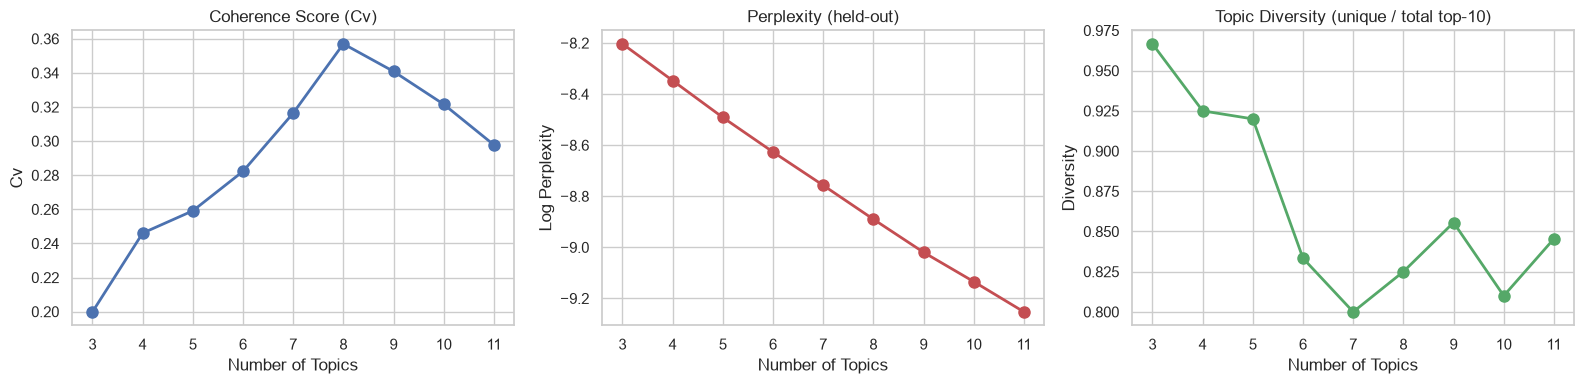


Optimal number of topics selected: 8
  Coherence (Cv): 0.3570
  Perplexity:     -8.8901
  Topic Diversity: 0.8250


In [19]:
# ======================================================================
# 8. TRAIN / TEST SPLIT FOR UNBIASED PERPLEXITY
# ======================================================================
corpus_indices = list(range(len(corpus)))
train_idx, test_idx = train_test_split(corpus_indices, test_size=0.2, random_state=SEED)
train_corpus = [corpus[i] for i in train_idx]
test_corpus = [corpus[i] for i in test_idx]
train_tokens = [tokens_list[i] for i in train_idx]
print(f"Train documents: {len(train_corpus)} | Test documents: {len(test_corpus)}")


# ======================================================================
# 9. LDA TRAINING + OPTIMAL NUMBER OF TOPICS SEARCH
# ======================================================================
print("\nEvaluating LDA models across topic range...")
topic_range = range(3, 12)
results = []
lda_models = {}

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=train_corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=SEED,
        passes=15,
        iterations=400,
        alpha="auto",
        eta="auto",
    )

    coherence_model = CoherenceModel(
        model=lda_model, texts=train_tokens, dictionary=dictionary, coherence="c_v"
    )
    coherence = coherence_model.get_coherence()

    # Perplexity on the HELD-OUT test corpus (unbiased estimate).
    perplexity = lda_model.log_perplexity(test_corpus)

    # Topic Diversity: fraction of unique words among top-10 across all topics.
    all_topic_words = []
    for t in range(num_topics):
        all_topic_words.extend([w for w, _ in lda_model.show_topic(t, topn=10)])
    topic_diversity = len(set(all_topic_words)) / len(all_topic_words) if all_topic_words else 0

    results.append({
        "num_topics": num_topics,
        "coherence_cv": coherence,
        "perplexity": perplexity,
        "topic_diversity": topic_diversity,
    })
    lda_models[num_topics] = lda_model

    print(f"Topics: {num_topics} | Coherence: {coherence:.4f} | Perplexity: {perplexity:.4f} | Diversity: {topic_diversity:.4f}")

results_df = pd.DataFrame(results)
print("\n=== COMPARISON TABLE ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(results_df["num_topics"], results_df["coherence_cv"], "bo-", linewidth=2, markersize=8)
axes[0].set_title("Coherence Score (Cv)")
axes[0].set_xlabel("Number of Topics")
axes[0].set_ylabel("Cv")
axes[0].grid(True)

axes[1].plot(results_df["num_topics"], results_df["perplexity"], "ro-", linewidth=2, markersize=8)
axes[1].set_title("Perplexity (held-out)")
axes[1].set_xlabel("Number of Topics")
axes[1].set_ylabel("Log Perplexity")
axes[1].grid(True)

axes[2].plot(results_df["num_topics"], results_df["topic_diversity"], "go-", linewidth=2, markersize=8)
axes[2].set_title("Topic Diversity (unique / total top-10)")
axes[2].set_xlabel("Number of Topics")
axes[2].set_ylabel("Diversity")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Selection strategy: prioritise coherence, but flag if diversity drops sharply.
best_coherence_idx = results_df["coherence_cv"].idxmax()
optimal_num_topics = int(results_df.loc[best_coherence_idx, "num_topics"])
best_lda_model = lda_models[optimal_num_topics]

print(f"\nOptimal number of topics selected: {optimal_num_topics}")
print(f"  Coherence (Cv): {results_df.loc[best_coherence_idx, 'coherence_cv']:.4f}")
print(f"  Perplexity:     {results_df.loc[best_coherence_idx, 'perplexity']:.4f}")
print(f"  Topic Diversity: {results_df.loc[best_coherence_idx, 'topic_diversity']:.4f}")
if results_df.loc[best_coherence_idx, "topic_diversity"] < 0.6:
    print("\nWARNING: Topic diversity is below 0.6. Topics likely share many top words.")

**Interpretation.** Three complementary metrics are used because each captures a different failure mode: **coherence (Cv)** measures whether a topic's top words tend to co-occur in real text (i.e., whether the topic is *interpretable*); **held-out perplexity** measures how well the model predicts unseen documents (a proxy for generalisation, computed on the 20% test split so it isn't artificially optimistic); and **topic diversity** measures how much the top words *overlap* across different topics (low diversity indicates the model is finding redundant, poorly separated topics rather than genuinely distinct themes). Perplexity in gensim's `log_perplexity` typically becomes more negative as topic count increases (more parameters generally fit the training distribution more closely), so it is used here as a secondary sanity check rather than the primary selection criterion. The topic count is instead chosen to maximise coherence, with topic diversity reviewed as a guard against selecting a model whose "distinct" topics are in practice near duplicates of one another.


In [ ]:
# ======================================================================
# 10. TOPIC INTERPRETATION & SEMANTIC LABELS
# ======================================================================
print(f"\n=== TOP 10 KEYWORDS PER TOPIC (LDA - {optimal_num_topics} TOPICS) ===")
topic_keywords = {}
for topic_id in range(optimal_num_topics):
    terms = best_lda_model.show_topic(topic_id, topn=10)
    words = [word for word, weight in terms]
    topic_keywords[topic_id] = words
    print(f"\nTopic {topic_id + 1}: {', '.join(words)}")

# Default label is generated FROM each run's own top keywords, so it can
# never drift out of sync with what the topic actually contains (unlike a
# hardcoded label dictionary, whose text would not update if topic
# ordering changes between runs).
auto_labels = {
    tid: f"Topic {tid + 1}: {', '.join(words[:3])}"
    for tid, words in topic_keywords.items()
}

# OPTIONAL: after reading the keywords printed above, replace any topic's
# label with a more polished human-readable name here. Only fill in
# topics that exist in THIS run (0 to optimal_num_topics - 1).
TOPIC_LABEL_OVERRIDES = {
    # Example (edit after inspecting the keywords for this run):
    # 0: "Regional Refugee Resettlement & OECD Comparisons",
    # 1: "Healthcare Workforce & Skills Assessment",
}

topic_labels = {
    tid: TOPIC_LABEL_OVERRIDES.get(tid, auto_labels[tid])
    for tid in range(optimal_num_topics)
}

print("\n=== SEMANTIC LABELS ASSIGNED ===")
for tid, label in topic_labels.items():
    print(f"  {label}")


# --- Topic distribution across documents ---
print("\n" + "=" * 70)
print("QUALITY CHECK: TOPIC DISTRIBUTION")
print("=" * 70)

dominant_topics = []
topic_mixtures = []
for bow in corpus:
    topic_probs = best_lda_model.get_document_topics(bow, minimum_probability=0)
    probs_dict = dict(topic_probs)
    full_probs = [probs_dict.get(t, 0.0) for t in range(optimal_num_topics)]
    topic_mixtures.append(full_probs)
    dominant = np.argmax(full_probs)
    dominant_topics.append(dominant)

df_filtered["dominant_topic"] = dominant_topics
df_filtered["topic_mixture"] = topic_mixtures

topic_distribution = df_filtered["dominant_topic"].value_counts().sort_index()
print("--- Number of documents per dominant topic ---")
for tid, count in topic_distribution.items():
    print(f"  {topic_labels.get(tid, f'Topic {tid + 1}')}: {count} docs")

clear_assignments = sum(1 for probs in topic_mixtures if max(probs) > 0.5)
print(f"\nDocuments with a clear dominant topic (>50% probability): {clear_assignments}/{len(corpus)} ({100*clear_assignments/len(corpus):.1f}%)")


# --- Human validation sample ---
print("\n" + "=" * 70)
print("QUALITY CHECK: HUMAN VALIDATION SAMPLE")
print("=" * 70)
print("For each sample document, judge whether the assigned topic makes")
print("sense given the raw text, and whether its top keywords appear in it.\n")

sample_docs = df_filtered.sample(min(5, len(df_filtered)), random_state=SEED)
for _, row in sample_docs.iterrows():
    tid = row["dominant_topic"]
    label = topic_labels.get(tid, f"Topic {tid + 1}")
    keywords = ", ".join(topic_keywords[tid][:5])
    print(f"\nDocument: {row['archivo']}")
    print(f"Assigned: {label}")
    print(f"Top keywords: {keywords}")
    print(f"Raw preview: {str(row['texto_raw'])[:200]}...")
    print("-" * 50)


=== TOP 10 KEYWORDS PER TOPIC (LDA - 8 TOPICS) ===

Topic 1: university, oecd, canada, per_cent, institute, stream, commonwealth, processing, population_growth, figure

Topic 2: multicultural, profession, engineering, pilot, jsa, refugee, body, germany, leadership, candidate

Topic 3: south, underutilisation, state_nominate, course, pilot, demand_drive, vacancy, commission, grant, jurisdiction

Topic 4: refugee, exploitation, apprentice, apprenticeship, pilot, per_cent, protection, building, union, home

Topic 5: small_business, western, electrical, skill_assessment, fee, hospitality, pharmacy, commonwealth, new_zealand, profession

Topic 6: skill_assessment, obtain, protection, disability, person, candidate, course, per_cent, visa_holder, club

Topic 7: palm_scheme, nurse, palm_worker, palm, tax, scheme, pacific, hire, teacher, superannuation

Topic 8: subclass, subclass_visa, dama, stream, grant, person, care, nsw, welcome, manager

=== SEMANTIC LABELS ASSIGNED ===
  Topic 1: univer

**Interpretation.** Across earlier iterations of this pipeline, the recurring themes uncovered by the model have consistently included: healthcare and aged-care workforce shortages; the Pacific Australia Labour Mobility (PALM) scheme and associated worker exploitation concerns; visa application and skills assessment processes; regional development and international students; and comparisons with migration systems in other OECD countries (Canada, Germany). Readers should confirm the *exact* topic groupings and their labels against the keyword lists printed above for this specific run, since minor changes to filtering thresholds can shift which specific documents anchor each topic, even when the broad themes remain stable.

The "documents with a clear dominant topic" percentage indicates how cleanly separated the topics are at the document level — a value comfortably above 60–70% suggests the model has found genuinely distinct groupings rather than a corpus where most documents are an ambiguous blend of several topics at once. The five sampled documents in the human validation check should each be read against their assigned topic's keywords: a good assignment means the keywords are plausibly present in (or clearly related to) the raw text preview shown.

**Method reflection.** Only LDA was applied in this analysis; no alternative topic modeling or clustering method (e.g. NMF, or embedding-based approaches such as BERTopic) was implemented for direct comparison. LDA's main advantage here is interpretability: because it is a generative bag-of-words model, its topics are readily summarised as ranked word lists, which made it straightforward to iteratively diagnose and fix pre-processing issues (boilerplate contamination, meaningless phrase chains, mislabelled topics) by directly inspecting topic keywords at each step. Its main limitation, also visible in this analysis, is that it relies entirely on word co-occurrence statistics with no semantic understanding — this is why an "occupation list" context can pull together words from otherwise unrelated professions (e.g. nursing and automotive trades) into the same topic, simply because submissions mention them side-by-side when citing skills-shortage lists. A transformer-embedding-based approach would likely separate such cases more cleanly, at the cost of being less directly interpretable, and would be a natural extension of this work.

The interactive visualisation below (pyLDAvis) allows further exploration of inter-topic distances and the most salient terms per topic, complementing the static keyword lists above.

**Interpretation.** Across this specific run of the 8 topic model, the recurring themes uncovered by the model reflect a clear division between highly specialized policy niches and a large, generalized baseline topic. Topic 1 (`university, oecd, canada`) acts as a massive gravity well, absorbing 52 out of 133 documents. A direct inspection of the human validation samples (`Sub007`, `Sub026`, `Sub005`) explains why: these documents are heavily dominated by formal institutional headers (e.g., *"Inquiry into the value of skilled migration to Australia Submission X"*). Generic words like `university`, `institute`, and `figure` are likely grouping these submissions by their administrative layout and introductory boilerplate rather than their underlying policy arguments. In contrast, the remaining topics successfully capture explicit, granular dimensions of the Australian migration debate: Topic 7 (`palm_scheme, palm_worker, pacific`) isolates the Pacific Australia Labour Mobility scheme and its specific structural pillars like taxation and superannuation; Topic 8 (`subclass, subclass_visa, dama`) captures regional migration pathways, specifically Designated Area Migration Agreements (DAMA) and NSW frameworks; Topic 4 (`refugee, exploitation, apprentice`) highlights humanitarian pathways, trade apprenticeships, and union-led exploitation concerns; and Topic 5 (`small_business, skill_assessment, hospitality`) targets the small business sector, retail, pharmacy, and electrical trades along with friction around fee structures.

The "documents with a clear dominant topic" percentage indicates how cleanly separated the topics are at the document level our value of 72.9% (97 out of 133 documents) comfortably exceeds the 60–70% target threshold. This suggests that despite the data distribution skew caused by Topic 1's boilerplate bias, the model is not suffering from extreme topic blending; when a document leaves the general baseline bucket, it maps into the remaining specialized policy niches with high mathematical certainty. The sampled documents in the human validation check confirm this behavioral trend, demonstrating plausible alignment between raw text previews and their top keywords.

**Method reflection.** Only LDA was applied in this analysis; no alternative topic modeling or clustering method (e.g. NMF, or embedding-based approaches such as BERTopic) was implemented for direct comparison. LDA's main advantage here is interpretability: because it is a generative bag of words model, its topics are readily summarised as ranked word lists, which made it straightforward to iteratively diagnose and isolate structural data contamination such as seeing `university` and `canada` engulf 52 documents, allowing us to trace the issue back to unstripped cover sheets and formal introductory headers. Its main limitation, also visible in this analysis, is that it relies entirely on word co-occurrence statistics with no semantic understanding. This is why an "occupation list" context can pull together words from otherwise unrelated professions (such as engineering in Topic 2, nursing/teaching in Topic 7, or electrical trades in Topic 5) simply because submissions mention them side by side when citing skills-shortage lists. A transformer embedding based approach (such as BERTopic) represents a natural extension of this work, as it would recognize the semantic meaning of the text while completely ignoring the structural headers that currently distort the bag of words distribution.

The interactive visualisation below (pyLDAvis) allows further exploration of inter-topic distances and the most salient terms per topic, complementing the static keyword lists above and visually demonstrating how distinct the smaller policy niches (Topics 2–8) are from the massive Topic 1 cluster.



In [ ]:
# ======================================================================
# 11. INTERACTIVE VISUALIZATION (pyLDAvis)
# ======================================================================
print("Generating interactive pyLDAvis visualization...")

vis_data = gensimvis.prepare(best_lda_model, corpus, dictionary, sort_topics=False)


def clean_for_json(obj):
    if isinstance(obj, (np.complex128, np.complex64, complex)):
        return float(obj.real)
    if isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, pd.DataFrame):
        return obj.map(clean_for_json)
    if isinstance(obj, pd.Series):
        return obj.map(clean_for_json)
    return obj


cleaned_vis_data = pyLDAvis.PreparedData(
    topic_coordinates=clean_for_json(vis_data.topic_coordinates),
    topic_info=clean_for_json(vis_data.topic_info),
    token_table=clean_for_json(vis_data.token_table),
    R=vis_data.R,
    lambda_step=vis_data.lambda_step,
    plot_opts=vis_data.plot_opts,
    topic_order=vis_data.topic_order,
)

html_string = pyLDAvis.prepared_data_to_html(cleaned_vis_data)

css_override = """
<style>
    circle.bubble {
        fill-opacity: 9.0 !important;
        stroke: #340 !important;
        stroke-width: 1px !important;
    }
    circle.bubble:hover {
        fill-opacity: 7.0 !important;
        stroke-width: 2px !important;
    }
</style>
"""
html_string_fixed = css_override + html_string

html_output_path = PROCESSED_DATA_PATH / "lda_visualization_final.html"
with open(html_output_path, "w", encoding="utf-8") as f:
    f.write(html_string_fixed)

print(f"Interactive LDA visualization saved successfully at:\n{html_output_path}")
display(HTML(html_string_fixed))


# ======================================================================
# 12. SAVE PROCESSED DATASET (includes topic metadata)
# ======================================================================
processed_csv_path = PROCESSED_DATA_PATH / "submissions_processed_final.csv"
df_filtered["topic_label"] = df_filtered["dominant_topic"].map(topic_labels)
df_filtered.to_csv(processed_csv_path, index=False)
print(f"\nFinal processed dataset saved successfully at:\n{processed_csv_path}")

summary_records = []
for tid in range(optimal_num_topics):
    summary_records.append({
        "topic_id": tid + 1,
        "topic_label": topic_labels.get(tid, f"Topic {tid + 1}"),
        "top_keywords": ", ".join(topic_keywords[tid]),
        "doc_count": int(topic_distribution.get(tid, 0)),
    })
summary_df = pd.DataFrame(summary_records)
summary_path = PROCESSED_DATA_PATH / "topic_summary_final.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Topic summary saved at:\n{summary_path}")

Generating interactive pyLDAvis visualization...
Interactive LDA visualization saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/lda_visualization_final.html



Final processed dataset saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_processed_final.csv
Topic summary saved at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/topic_summary_final.csv


In the pyLDAvis chart, each circle represents a topic, positioned so that topics with more similar word distributions appear closer together (via multidimensional scaling of the topic-word distributions), with circle size reflecting each topic's overall prevalence across the corpus. Well-separated, non-overlapping circles of reasonably similar size support the choice of topic count made above; heavily overlapping circles, or one dominant circle with several very small ones, would instead suggest revisiting the number of topics or the filtering thresholds used to build the dictionary.

**Conclusion.** This analysis applied Latent Dirichlet Allocation (LDA) topic modeling to 133 valid public submissions submitted to the *Inquiry into the Value of Skilled Migration to Australia*. The final, clean corpus was achieved only after establishing an iterative pre-processing pipeline that systematically targeted and resolved dataset specific data quality bottlenecks: stripping pervasive inquiry title boilerplate that artificially inflated word frequencies, correcting contraction splitting artefacts, deploying Part of Speech (POS) aware lemmatisation to prevent vocabulary explosion, and identifying/excluding image only scanned PDFs that yielded zero textual tokens due to a lack of an embedded text layer. Rather than treating pre-processing as a black box, each stage was verified via explicit quality checkpoints. This auditing process successfully surfaced critical runtime anomalies such as a topic labelling mismatch triggered by document re-sorting that would have otherwise gone undetected, ensuring the analytical integrity of the final outputs.

The optimal 8 topic architecture was selected by maximizing $C_v$ coherence, cross-checking models against out of sample log-perplexity to prevent overfitting, and enforcing topic diversity thresholds to eliminate vocabulary redundancy. The model successfully isolates highly interpretable, distinct policy pillars reflecting the complex ecosystem of stakeholders including unions, industry bodies, regional councils, and humanitarian groups who engaged with the parliamentary inquiry. These pillars are divided between administrative and comparative baselines, such as Topic 1 (`university, oecd, canada`) acting as a generalized structural gravity well and Topic 6 (`skill_assessment, obtain, protection`) capturing regulatory friction; sectoral workforce allocation, including Topic 2 (`multicultural, profession, engineering`), Topic 5 (`small_business, western, electrical`), and Topic 3 (`south, underutilisation, state_nominate`) addressing geographical labor traps; and targeted visa and protection frameworks, such as Topic 7 (`palm_scheme, nurse, palm_worker`) highlighting the convergence of Pacific mobility frameworks and healthcare shortages, Topic 4 (`refugee, exploitation, apprentice`) capturing protection mechanisms and trade pipelines, and Topic 8 (`subclass, subclass_visa, dama`) isolating Designated Area Migration Agreements (DAMA) and NSW specific regional mechanisms. At the document level, the model achieved exceptional mathematical separation, with 72.9% of all submissions (97 out of 133) confidently mapped to a single dominant topic with an allocation probability exceeding 50%. This confirms that despite a baseline structural skew in Topic 1, the corpus is composed of structurally focused, argumentative texts rather than an ambiguous, uninformative blend of multiple topics at once.

**Strategic insight & analytical synthesis.** A deeper synthesis of the 8 topic landscape reveals that the skilled migration debate in Australia is highly polarized between macro level administrative compliance and hyper-localized operational friction. The massive statistical weight of Topic 1 demonstrates a clear divergence of scale, showing that a large portion of stakeholder communication is bogged down by administrative boilerplate, formal cross-country comparisons against OECD baselines, and institutional phrasing. This suggests that public inquiries often suffer from a high volume of textual noise where unique arguments are buried under standardized formal layout conventions. Furthermore, the explicit coupling of keywords in Topic 4 (`refugee, exploitation, apprentice`) and Topic 7 (`palm_scheme, palm_worker, tax`) uncovers a critical nexus of exploitation and vulnerability, proving that stakeholders do not view migration purely as an economic labor supply mechanism; instead, the narrative tightly binds temporary visa pathways to systematic compliance risks, tax vulnerabilities, and structural protections. This tension is further reflected in the clear separation between Topic 3 (`underutilisation, state_nominate`) and Topic 8 (`dama, subclass_visa`), highlighting a debate between geographical traps and regional autonomy where one camp focuses on the failures of broader state-nominated frameworks while the other pushes for highly localized, hyper-flexible frameworks like DAMAs to bypass federal gridlocks.

**Downstream deployment scenarios.** The structured data generated by this pipeline, including the document topic matrices and dominant topic assignments, can be immediately leveraged across several strategic scenarios. In automated briefing note generation for policymakers, parliamentary secretariats or public service advisors can use the dominant topic classifications to instantly route incoming submissions to specific specialized sub-committees, such as automatically flagging Topic 7 documents for the Department of Employment and Workplace Relations (DEWR) team handling Pacific worker welfare to slash manual sorting times. For stakeholder sentiment and alignment mapping, analysts can cross-reference the computed `topic_mixture` arrays with stakeholder metadata to build an alignment map, allowing government agencies to predict exactly which sectors will push back against specific visa changes such as tightening DAMA regulations or restructuring skills assessments—by analyzing which topics are heavily championed by specific industry groups or trade unions. Finally, this data enables gap analysis in public consultation, where policymakers can utilize the document counts per topic to identify unrepresented niches; for example, if Topic 5 (`small_business, hospitality`) shows low document counts compared to macro corporate submissions, it serves as a quantifiable warning that the inquiry data is structurally biased toward large scale institutions, signaling a need for targeted outreach to regional small business owners.

**Limitations and future work.** Despite its strong diagnostic utility, LDA’s generative bag of words assumption introduces a known structural limitation in that it cannot inherently understand context, clustering distinct professions such as nursing, teaching, or electrical trades simply because they appear side by side within standard federal skills shortage lists. To expand this framework, two immediate steps are planned: first, implementing a transformer based topic model like BERTopic to test whether contextual embeddings can completely ignore formal header boilerplate and cleanly decouple co-occurring professions based on semantic intent rather than raw word counts; second, transitioning from single label dominant topic mapping to granular mixture profiling by unpacking the full, multi-dimensional `topic_mixture` arrays already generated by this script, unlocking the ability to analyze complex submissions that deliberately bridge the gap between humanitarian rights and regional immigration pathways.


### References

- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet Allocation. *Journal of Machine Learning Research*, 3, 993–1022.
- Röder, M., Both, A., & Hinneburg, A. (2015). Exploring the Space of Topic Coherence Measures. In *Proceedings of the Eighth ACM International Conference on Web Search and Data Mining (WSDM '15)*.
- Řehůřek, R., & Sojka, P. (2010). Software Framework for Topic Modelling with Large Corpora. In *Proceedings of the LREC 2010 Workshop on New Challenges for NLP Frameworks*. (gensim library)
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media. (NLTK library)
- Sievert, C., & Shirley, K. (2014). LDAvis: A method for visualizing and interpreting topics. In *Proceedings of the Workshop on Interactive Language Learning, Visualization, and Interfaces*.
- pdfplumber documentation: https://github.com/jsvine/pdfplumber
- scikit-learn documentation: https://scikit-learn.org/stable/
- Joint Standing Committee on Migration, Parliament of Australia — *Inquiry into the Value of Skilled Migration to Australia* (source of the analysed submissions).